In [ ]:
import pytz
from datetime import datetime
from dateutil.relativedelta import relativedelta
from skyfield.api import load, wgs84, EarthSatellite

## Standard satellite TLE query

In [ ]:
# Download satellite TLE data from NORAD
stations_url = 'https://www.celestrak.com/NORAD/elements/stations.txt'
satellites = load.tle_file(stations_url)
by_name = {sat.name: sat for sat in satellites}

In [ ]:
ts = load.timescale()
# satellite = EarthSatellite(line1, line2, 'HST', ts)
satellite=by_name['ISS (NAUKA)']
print(satellite)

# Get the current time in a timezone-aware fashion.

tz = pytz.timezone('UTC')
dt = tz.localize(datetime.utcnow())
print(f"Exectution time: {dt:%Y-%m-%d %H:%M:%S %Z}\n")

# Split the next 200 minutes into a collection of 101-evenly
# spaced Timescales (every two minutes, plus endpoints)

t0 = ts.utc(dt)
t1 = ts.utc(dt + relativedelta(minutes=100))
timescales = ts.linspace(t0, t1, 1000)

# calculate the subpoints.

geocentrics = satellite.at(timescales)
points= wgs84.subpoint_of(geocentrics)

In [ ]:
longitude=(points.longitude.degrees)
latitude=(points.latitude.degrees)
print(f'Altitude is {wgs84.height_of(satellite.at(t0)).km}')

In [ ]:
from src2.shapecheck import shapecheck
shapecheck(longitude,latitude,'')

## Customize satellite with self defined orbital elements

In [ ]:
ts = load.timescale()


line1='1 39084U 13008A   24057.13689462  .00000700  00000-0  16532-3 0  9990'
line2='2 39084  98.1956 128.5395 0001009 108.7107 251.4201 14.57123403587095'
satellite = EarthSatellite(line1, line2, 'Landsat-8', ts)
print(satellite)

# Get the current time in a timezone-aware fashion.

tz = pytz.timezone('UTC')
dt = tz.localize(datetime.utcnow())
print(f"Exectution time: {dt:%Y-%m-%d %H:%M:%S %Z}\n")

# Split the next 200 minutes into a collection of 101-evenly
# spaced Timescales (every two minutes, plus endpoints)

t0 = ts.utc(dt+relativedelta(minutes=1500))
t1 = ts.utc(dt + relativedelta(minutes=1500+525960))
timescales = ts.linspace(t0, t1, 100000)

# calculate the subpoints.

geocentrics = satellite.at(timescales)

subpoints = wgs84.subpoint_of(geocentrics)

In [ ]:
finvel=np.sqrt((geocentrics.velocity.km_per_s[0])**2+(geocentrics.velocity.km_per_s[1])**2+(geocentrics.velocity.km_per_s[2])**2)

In [ ]:
finvel

In [ ]:
epoch=(t0.astimezone(tz))
print(f"epoch : {epoch:%Y-%m-%d %H:%M:%S %Z}\n")

In [ ]:
# 2024-02-26 03:17:08

In [ ]:
Lon,Lat=subpoints.longitude.degrees,subpoints.latitude.degrees

In [ ]:
from src2.shapecheck import shapecheck
shapecheck(Lon,Lat,'Ground track of one orbit')
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper_images/GT.pdf',dpi=600,bbox_inches='tight')


In [ ]:
# import pandas as pd
# df=pd.DataFrame({'Lon':Lon,'Lat':Lat})
# df.to_csv('/home/pratush/Desktop/neworbit.csv')

In [ ]:
Lon[0],Lat[0]

## Altitude of the satellite

In [382]:
from astropy.constants import R_earth,M_earth,GM_earth
import numpy as np

In [383]:
line_2_elements = line2.split()
days = line_2_elements[-1]
days=float(days)
time=(1/days)*24*3600

In [384]:
R_e=R_earth.to('m').value
GM_earth=GM_earth.to('m3/s2').value

In [385]:
alt=(((((time**2)*GM_earth)/(4*(np.pi**2)))**(1/3))-R_e)/1000

In [386]:
print(alt)

702.5142866310933


(array([133.,  59.,  50.,  44.,  44.,  45.,  48.,  54.,  71., 452.]),
 array([7.48806849, 7.48986841, 7.49166832, 7.49346823, 7.49526815,
        7.49706806, 7.49886797, 7.50066788, 7.5024678 , 7.50426771,
        7.50606762]),
 <BarContainer object of 10 artists>)

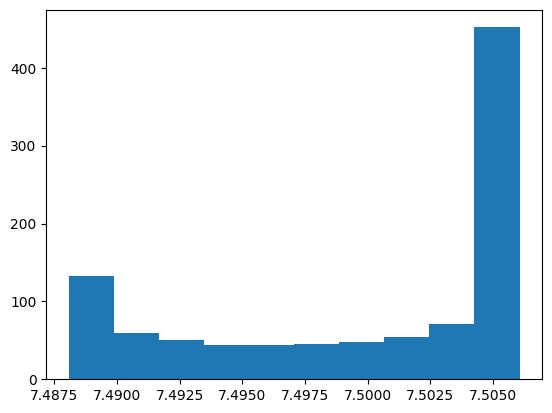

In [85]:
import matplotlib.pyplot as plt

plt.hist(finvel)

In [158]:
distdf=pd.read_csv('/home/pratush/Yogen_STARFIRE/distances2.csv')

In [159]:
ip=distdf['InputID'].to_numpy()

In [160]:
op=distdf['TargetID'].to_numpy()

In [161]:
distance=distdf['Distance'].to_numpy()